# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [1]:
!python -m pip install kaggle==1.6.12

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install --target=/workspace ucimlrepo numpy==1.24.3

  Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
  Using cached numpy-1.24.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Using cached certifi-2026.6.17-py3-none-any.whl (133 kB)
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

**Note:** Restart the kernel to use updated package(s).

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


This project investigates how air pollution levels differ across countries and whether highly populated countries tend to have higher average PM2.5 pollution levels.

I will wrangle a world population dataset and an IQAir city-level air quality dataset. 

The population dataset provides country-level population values across multiple years, while the air quality dataset provides city-level PM2.5 values that can be aggregated to country level. 

After cleaning and combining the datasets, I will compare China, India, European countries, and other countries using population and average air pollution indicators.

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### Dataset 1

Type: CSV File

Method:
Programmatically downloaded from a URL using pandas.read_csv().

Dataset:
World Population Dataset (derived from World Bank population statistics).

Dataset variables:

* Country Name: Name of the country or region.
* Country Code: Unique country identifier.
* Year: Observation year.
* Population: Total population for the country in the given year.

Reason for selection:

This dataset contains yearly population values for countries around the world and provides a country-level variable that can be combined with air quality data for analysis. Population was selected because it allows investigation of whether larger populations are associated with higher air pollution levels.

In [4]:
import pandas as pd

population_url = (
    "https://raw.githubusercontent.com/datasets/population/master/data/population.csv"
)

population_long_raw = pd.read_csv(population_url)

population_raw = population_long_raw.pivot(
    index=["Country Name", "Country Code"],
    columns="Year",
    values="Value"
).reset_index()

population_raw.columns = population_raw.columns.astype(str)

population_raw.head()

Year,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,AFG,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,10505959.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
1,Africa Eastern and Southern,AFE,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,153281203.0,157704381.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0
2,Africa Western and Central,AFW,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,111246953.0,113795019.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0
3,Albania,ALB,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,1914573.0,1965598.0,...,2731293.0,2689469.0,2648285.0,2607733.0,2567801.0,2528480.0,2489762.0,2451636.0,2414095.0,2377128.0
4,Algeria,DZA,11424922.0,11628883.0,11800771.0,11982118.0,12179813.0,12365976.0,12590069.0,12876118.0,...,40019529.0,40850721.0,41689299.0,42505035.0,43294546.0,44042091.0,44761099.0,45477389.0,46164219.0,46814308.0


In [5]:
print("Downloaded population shape:", population_long_raw.shape)
print("Reshaped population shape:", population_raw.shape)

Downloaded population shape: (17195, 4)
Reshaped population shape: (265, 67)


In [6]:
population_long_raw.to_csv(
    "data/raw/world_population_programmatic_raw.csv",
    index=False
)

population_raw.to_csv(
    "data/raw/world_population_reshaped_raw.csv",
    index=False
)

#### Dataset 2

Type: CSV File

Method:
Manually downloaded from Kaggle and loaded locally using pandas.

Dataset:
IQAir Air Quality Index Dataset.

Dataset variables:

* City: City name and country.
* 2021: Average PM2.5 concentration for 2021.
* JAN(2021) - DEC(2021): Monthly PM2.5 measurements.
* Rank: Pollution ranking of the city.

Reason for selection:

This dataset contains PM2.5 air pollution measurements for cities around the world. After aggregating city-level measurements to country level, it can be combined with population data to investigate differences in air pollution and the relationship between population size and pollution levels.

In [7]:
air_raw = pd.read_csv("data/raw/AIR QUALITY INDEX (by cities) - IQAir.csv")
air_raw.head()

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017
0,1,"Bhiwadi, India",106.2,145.8,129.8,120.2,125.7,86.5,95.9,55.6,55.4,37.1,91.1,188.6,136.6,95.5,83.4,125.4,-
1,2,"Ghaziabad, India",102.0,199.9,172.2,97.8,86.3,52.9,47.2,35.3,37.6,30.8,89.7,218.3,163,106.6,110.2,135.2,144.6
2,3,"Hotan, China",101.5,-,-,158,91.1,167.4,57.4,70.9,93.2,79.3,126.1,111.5,62.6,110.2,110.1,116,91.9
3,4,"Delhi, India",96.4,183.7,142.2,80.5,72.9,47.4,47.1,35.6,36.9,30.2,73.7,224.1,186.4,84.1,98.6,113.5,108.2
4,5,"Jaunpur, India",95.3,182.2,143.5,91,70,51.1,40.7,33.5,34.2,36.8,75.7,196,195.7,-,-,-,-


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [8]:
print("Population shape:", population_raw.shape)
print("Air quality shape:", air_raw.shape)

Population shape: (265, 67)
Air quality shape: (6475, 19)


In [9]:
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/cleaned", exist_ok=True)

population_raw.to_csv("data/raw/world_population_raw.csv", index=False)
air_raw.to_csv("data/raw/iqair_city_air_quality_raw.csv", index=False)

#### Relationship between the datasets

Both datasets contain geographic information that can be linked at the country level. The population dataset provides total population values, while the IQAir dataset provides air pollution measurements. Combining them enables analysis of how population size relates to PM2.5 pollution levels and allows comparison between countries such as China, India, and selected European countries.

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

In [10]:
population_raw.info()
population_raw.describe()
population_raw.isna().sum().sort_values(ascending=False).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 67 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  265 non-null    object 
 1   Country Code  265 non-null    object 
 2   1960          264 non-null    float64
 3   1961          264 non-null    float64
 4   1962          264 non-null    float64
 5   1963          264 non-null    float64
 6   1964          264 non-null    float64
 7   1965          264 non-null    float64
 8   1966          264 non-null    float64
 9   1967          264 non-null    float64
 10  1968          264 non-null    float64
 11  1969          264 non-null    float64
 12  1970          264 non-null    float64
 13  1971          264 non-null    float64
 14  1972          264 non-null    float64
 15  1973          264 non-null    float64
 16  1974          264 non-null    float64
 17  1975          264 non-null    float64
 18  1976          264 non-null    

Year
1982    1
1974    1
1989    1
1988    1
1987    1
1986    1
1985    1
1984    1
1983    1
1981    1
1980    1
1979    1
1978    1
1976    1
1975    1
1977    1
1973    1
1966    1
1960    1
1961    1
dtype: int64

In [11]:
air_raw.info()
air_raw.describe()
air_raw.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6475 entries, 0 to 6474
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Rank       6475 non-null   int64  
 1   City       6475 non-null   object 
 2   2021       6475 non-null   float64
 3   JAN(2021)  6475 non-null   object 
 4   FEB(2021)  6475 non-null   object 
 5   MAR(2021)  6475 non-null   object 
 6   APR(2021)  6475 non-null   object 
 7   MAY(2021)  6475 non-null   object 
 8   JUN(2021)  6475 non-null   object 
 9   JUL(2021)  6475 non-null   object 
 10  AUG(2021)  6475 non-null   object 
 11  SEP(2021)  6475 non-null   object 
 12  OCT(2021)  6475 non-null   object 
 13  NOV(2021)  6475 non-null   object 
 14  DEC(2021)  6475 non-null   object 
 15  2020       6475 non-null   object 
 16  2019       6475 non-null   object 
 17  2018       6475 non-null   object 
 18  2017       6475 non-null   object 
dtypes: float64(1), int64(1), object(17)
memory usage

Rank         0
AUG(2021)    0
2018         0
2019         0
2020         0
DEC(2021)    0
NOV(2021)    0
OCT(2021)    0
SEP(2021)    0
JUL(2021)    0
City         0
JUN(2021)    0
MAY(2021)    0
APR(2021)    0
MAR(2021)    0
FEB(2021)    0
JAN(2021)    0
2021         0
2017         0
dtype: int64

In [12]:
air_raw.sample(10)

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017
3596,3597,"Piamborno, Italy",10.0,18.5,19.2,13.8,8.6,2.7,5.4,5.1,4.4,6.7,7,10.5,22,-,-,-,-
3017,3018,"Mount Airy, USA",11.1,12.5,15.5,8.6,9.2,7.9,9.7,19,14,9.4,8.2,8.8,9.9,9.7,11.9,-,-
677,678,"Huzhou, China",25.3,41.4,24.9,27.1,23.5,23.2,20.1,14.3,19.7,21.6,20.3,25.8,41.2,26.2,32.2,35.1,41.1
224,225,"Fushun, China",39.7,67.3,60.9,67.2,35.3,29.1,20.9,20.5,21.4,17.7,34,53.2,46,43.3,43,41.2,47.2
5103,5104,"Sakaihigashi, Japan",7.8,7.7,10.4,11.1,8.6,8.8,9.7,7,7,5.4,5.1,5.6,5.9,-,-,-,-
4257,4258,"Porsgrunn, Norway",9.0,13.3,11.4,8.1,4.8,6.6,9,7.9,5.5,6.6,8.2,10,16.9,7.5,7.6,7.5,7.4
3509,3510,"Toppenish, USA",10.2,10.7,3.3,7.2,5.9,4.3,6.6,8.1,29.2,17.2,7,9.5,8.2,14.9,10,10.4,13.1
2980,2981,"Plymouth, USA",11.2,13.7,13,10,11.3,10.3,8.8,16.6,15.3,6,9.2,8.8,9.6,-,-,-,-
3028,3029,"Mission, USA",11.1,8.8,11.5,12.1,16.6,10.7,9.7,11.7,10.5,11.4,8.9,7.1,14,10.2,11,10.3,9.5
6201,6202,"Junction City, USA",5.3,6.3,4.2,4.4,3.3,2.8,5.1,4.6,6.9,7,6.6,7,4.6,13.7,6.3,-,-


### Quality Issue 1: Missing population values

The population dataset contains missing values in several year columns. This is a completeness issue because missing population values could affect country-level population comparisons and later merging with the air quality dataset.

Visual Assessment:

I displayed the rows containing missing values using population_raw[population_raw.isna().any(axis=1)]. This visual check is useful because it shows which records are affected and helps confirm whether the missing values are limited to a small number of rows.

Programmatic Assessment:

I used population_raw.isna().sum() to count the number of missing values in each column. This programmatic check is appropriate because it quantifies the scale of the missing-data issue and identifies which columns contain missing values.

In [13]:
population_raw[population_raw.isna().any(axis=1)]

Year,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
260,West Bank and Gaza,PSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4270092.0,4367088.0,4454805.0,4569087.0,4685306.0,4803269.0,4922749.0,5043612.0,5165775.0,5289152.0


In [14]:
population_raw.isna().sum().sort_values(ascending=False).head(20)

Year
1982    1
1974    1
1989    1
1988    1
1987    1
1986    1
1985    1
1984    1
1983    1
1981    1
1980    1
1979    1
1978    1
1976    1
1975    1
1977    1
1973    1
1966    1
1960    1
1961    1
dtype: int64

### Quality Issue 2: Annual PM2.5 columns used in this analysis are stored as incorrect data types

The annual PM2.5 columns used in this analysis, especially 2021, 2020, 2019, 2018, and 2017, are stored as object data types instead of numeric data types. This is a validity issue because these columns represent pollution measurements and must be numeric for calculations, aggregation, and visualization.

Visual Assessment:

I inspected the annual PM2.5 columns using head(). This visual check is appropriate because it shows the actual values in the selected columns and confirms that they contain pollution measurements that should be treated as numbers.

Programmatic Assessment:

I used dtypes to check the data types of the columns. This programmatic check is appropriate because it confirms whether pandas is storing the PM2.5 measurement columns as numeric or non-numeric data.

In [15]:
air_raw[["2021", "2020", "2019", "2018", "2017"]].head()

,2021,2020,2019,2018,2017
0,106.2,95.5,83.4,125.4,-
1,102.0,106.6,110.2,135.2,144.6
2,101.5,110.2,110.1,116,91.9
3,96.4,84.1,98.6,113.5,108.2
4,95.3,-,-,-,-


In [16]:
air_raw.dtypes

Rank           int64
City          object
2021         float64
JAN(2021)     object
FEB(2021)     object
MAR(2021)     object
APR(2021)     object
MAY(2021)     object
JUN(2021)     object
JUL(2021)     object
AUG(2021)     object
SEP(2021)     object
OCT(2021)     object
NOV(2021)     object
DEC(2021)     object
2020          object
2019          object
2018          object
2017          object
dtype: object

Justification:

I assessed this issue programmatically using dtypes to check the data type of each column. I also inspected sample rows visually using head() to confirm that the PM2.5 columns contain measurement values that should be numeric.

### Tidiness Issue 1: Years stored as columns

The population dataset is not tidy because years are stored as separate columns from 1960 to 2024. Each year should be a value in a single Year column, with the population stored in a separate Population column.

Visual Assessment:

I inspected the dataset using population_raw.head(). This visual check is appropriate because it shows the wide structure of the dataset, where many year values appear as separate column headers.

Programmatic Assessment:

I used population_raw.columns.tolist() to inspect all column names. This programmatic check is appropriate because it confirms that many columns represent years, which violates the tidy data rule that each variable should form a column.

In [17]:
# Inspecting the dataframe visually
population_raw.head()

Year,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,AFG,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,10505959.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
1,Africa Eastern and Southern,AFE,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,153281203.0,157704381.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0
2,Africa Western and Central,AFW,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,111246953.0,113795019.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0
3,Albania,ALB,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,1914573.0,1965598.0,...,2731293.0,2689469.0,2648285.0,2607733.0,2567801.0,2528480.0,2489762.0,2451636.0,2414095.0,2377128.0
4,Algeria,DZA,11424922.0,11628883.0,11800771.0,11982118.0,12179813.0,12365976.0,12590069.0,12876118.0,...,40019529.0,40850721.0,41689299.0,42505035.0,43294546.0,44042091.0,44761099.0,45477389.0,46164219.0,46814308.0


In [18]:
# Inspecting the dataframe programmatically
population_raw.columns.tolist()

['Country Name',
 'Country Code',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024']

### Tidiness Issue 2: City and country stored together in one column

The air quality dataset is not tidy because the City column contains both city and country in the same field, for example "Bhiwadi, India" and "Hotan, China". City and country are two separate variables, so they should be stored in separate columns.

Visual Assessment:

I inspected the dataset using air_raw.head(). This visual check is appropriate because it shows that the City column contains combined city-country values.

Programmatic Assessment:

I inspected air_raw["City"].head(10). This programmatic check is appropriate because it focuses directly on the affected column and confirms that the same combined pattern appears across multiple rows.

In [19]:
# Inspecting the dataframe visually
air_raw.head()

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017
0,1,"Bhiwadi, India",106.2,145.8,129.8,120.2,125.7,86.5,95.9,55.6,55.4,37.1,91.1,188.6,136.6,95.5,83.4,125.4,-
1,2,"Ghaziabad, India",102.0,199.9,172.2,97.8,86.3,52.9,47.2,35.3,37.6,30.8,89.7,218.3,163,106.6,110.2,135.2,144.6
2,3,"Hotan, China",101.5,-,-,158,91.1,167.4,57.4,70.9,93.2,79.3,126.1,111.5,62.6,110.2,110.1,116,91.9
3,4,"Delhi, India",96.4,183.7,142.2,80.5,72.9,47.4,47.1,35.6,36.9,30.2,73.7,224.1,186.4,84.1,98.6,113.5,108.2
4,5,"Jaunpur, India",95.3,182.2,143.5,91,70,51.1,40.7,33.5,34.2,36.8,75.7,196,195.7,-,-,-,-


In [20]:
# Inspecting the dataframe programmatically
air_raw["City"].head(10)

0          Bhiwadi, India
1        Ghaziabad, India
2            Hotan, China
3            Delhi, India
4          Jaunpur, India
5    Faisalabad, Pakistan
6            Noida, India
7    Bahawalpur, Pakistan
8      Peshawar, Pakistan
9           Bagpat, India
Name: City, dtype: object

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [21]:
population_clean = population_raw.copy()
air_clean = air_raw.copy()

### **Quality Issue 1: Missing population values*

The population dataset contains missing values in several year columns. Missing values can affect calculations and comparisons if not handled appropriately.


Assessment Justification:

I assessed this issue programmatically using isna().sum() to count missing values in each column. I also visually inspected rows containing missing values using filtering to identify which records were affected and to understand the extent of the missing data.

In [22]:
population_clean = population_clean.dropna()

In [23]:
population_clean.isna().sum().sum()

0

Validation:

The result is 0, which confirms that all missing values were successfully removed from the population dataset.

Justification:

I removed rows containing missing population values using dropna() because the missing values were limited to a small number of records. Keeping incomplete records could affect population comparisons and later analysis. After cleaning, I validated the result by checking that the total number of missing values in the dataset was equal to zero.

### **Quality Issue 2: Annual PM2.5 columns used in this analysis are stored as incorrect data types**

The annual PM2.5 columns used in this analysis contain values stored as text, including the placeholder "-" used to represent missing values. This prevents the selected annual PM2.5 columns from being used directly for numerical analysis.


Assessment Justification:

I assessed this issue by inspecting the annual PM2.5 columns used in this analysis and their data types using dtypes. I also examined sample values and identified the presence of "-" placeholders, which indicated that the columns were not being interpreted as purely numeric data.

In [24]:
# Replace invalid missing-value placeholders with NaN
air_clean = air_clean.replace("-", np.nan)

# Convert PM2.5 columns to numeric data types
pm25_cols = ["2021", "2020", "2019", "2018", "2017"]

air_clean[pm25_cols] = air_clean[pm25_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [25]:
air_clean[pm25_cols].dtypes

2021    float64
2020    float64
2019    float64
2018    float64
2017    float64
dtype: object

In [26]:
air_clean[pm25_cols].head()

,2021,2020,2019,2018,2017
0,106.2,95.5,83.4,125.4,NaN
1,102.0,106.6,110.2,135.2,144.6
2,101.5,110.2,110.1,116.0,91.9
3,96.4,84.1,98.6,113.5,108.2
4,95.3,NaN,NaN,NaN,NaN


In [27]:
air_clean[pm25_cols].isna().sum()

2021       0
2020    2207
2019    2422
2018    3999
2017    4194
dtype: int64

Validation:

The selected annual PM2.5 columns used in this analysis are now stored as numeric (float64) data types. The output also confirms that invalid "-" placeholders were successfully converted to NaN values, allowing the columns to be used correctly for analysis and aggregation.

Justification:

I replaced "-" values with NaN because they are invalid placeholders in the annual PM2.5 columns used for this analysis. I then converted the selected annual PM2.5 columns to numeric data types so they can be used for calculations, aggregation, and visualization. I did not convert the monthly PM2.5 columns because they are not used in the final analysis. I validated the cleaning by checking that the selected annual PM2.5 columns are now stored as float64.

### **Tidiness Issue 1: Years stored as columns**

Population years are stored as separate columns rather than observations.

In [28]:
population_clean = population_clean.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="Year",
    value_name="Population"
)

In [29]:
population_clean.head()

,Country Name,Country Code,Year,Population
0,Afghanistan,AFG,1960,9035043.0
1,Africa Eastern and Southern,AFE,1960,130075728.0
2,Africa Western and Central,AFW,1960,97630925.0
3,Albania,ALB,1960,1608800.0
4,Algeria,DZA,1960,11424922.0


Justification:

I reshaped the dataset from wide format to long format using melt(). This creates a single Year column and a single Population column, which follows tidy data principles and makes analysis and visualization easier. I validated the transformation by confirming that the resulting dataframe contains the columns Country Name, Country Code, Year, and Population.

### **Tidiness Issue 2: City and country combined**

City and country are stored together in a single column.

In [30]:
air_clean[["City_Name", "Country"]] = air_clean["City"].str.split(
    ", ",
    n=1,
    expand=True
)

In [31]:
air_clean[["City", "City_Name", "Country"]].head()

,City,City_Name,Country
0,"Bhiwadi, India",Bhiwadi,India
1,"Ghaziabad, India",Ghaziabad,India
2,"Hotan, China",Hotan,China
3,"Delhi, India",Delhi,India
4,"Jaunpur, India",Jaunpur,India


Justification:

I split the City column into separate City_Name and Country columns because they represent two different variables. Separating them improves data organization and simplifies grouping, filtering, and aggregation by country. I validated the transformation by inspecting the new columns and confirming that city and country values were correctly separated.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

### Keep only 2021 population

Since your air quality data focuses on 2021, extract only 2021 population data.

In [32]:
population_2021 = population_clean[
    population_clean["Year"] == "2021"
].copy()

population_2021.head()

,Country Name,Country Code,Year,Population
16104,Afghanistan,AFG,2021,40000412.0
16105,Africa Eastern and Southern,AFE,2021,713090928.0
16106,Africa Western and Central,AFW,2021,485920997.0
16107,Albania,ALB,2021,2489762.0
16108,Algeria,DZA,2021,44761099.0


In [33]:
population_2021.shape

(264, 4)

### Aggregate air quality to country level

Compute average PM2.5 by country.

In [34]:
country_air = (
    air_clean
    .groupby("Country")["2021"]
    .mean()
    .reset_index()
)

country_air.head()

,Country,2021
0,Afghanistan,37.5
1,Albania,12.5
2,Algeria,20.0
3,Andorra,7.3
4,Angola,11.0


In [35]:
country_air.shape

(118, 2)

### Rename column for clarity

In [36]:
country_air.rename(
    columns={"2021": "Avg_PM25_2021"},
    inplace=True
)

### Inspect country names

In [37]:
sorted(country_air["Country"].unique())[:20]

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Belgium',
 'Bonaire, Saint Eustatius and Saba',
 'Bosnia Herzegovina',
 'Brazil',
 'Bulgaria',
 'Cambodia',
 'Canada']

In [38]:
sorted(population_2021["Country Name"].unique())[:20]

['Afghanistan',
 'Africa Eastern and Southern',
 'Africa Western and Central',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Arab World',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas, The',
 'Bahrain',
 'Bangladesh',
 'Barbados']

### Create matching column

In [39]:
population_2021["Country"] = population_2021["Country Name"]

### Merge

In [40]:
combined_df = pd.merge(
    population_2021,
    country_air,
    on="Country",
    how="inner"
)

In [41]:
combined_df = combined_df[
    ["Country", "Country Code", "Year", "Population", "Avg_PM25_2021"]
]


### Validate

In [42]:
combined_df.head()

,Country,Country Code,Year,Population,Avg_PM25_2021
0,Afghanistan,AFG,2021,40000412.0,37.5
1,Albania,ALB,2021,2489762.0,12.5
2,Algeria,DZA,2021,44761099.0,20.0
3,Andorra,AND,2021,78364.0,7.3
4,Angola,AGO,2021,34532429.0,11.0


In [43]:
combined_df.shape

(97, 5)

In [44]:
print("Population countries in 2021:", population_2021["Country"].nunique())
print("Air quality countries:", country_air["Country"].nunique())
print("Countries after merge:", combined_df["Country"].nunique())

Population countries in 2021: 264
Air quality countries: 118
Countries after merge: 97


Merge Quality Check:

This check shows how many unique countries existed in each dataset before the merge and how many countries remained after the inner merge. It helps identify whether country-name mismatches caused records to be excluded from the final combined dataset.

In [45]:
combined_df.columns

Index(['Country', 'Country Code', 'Year', 'Population', 'Avg_PM25_2021'], dtype='object')

Validation:

The final combined dataset contains 97 rows and 5 columns. The first rows show that country, country code, year, population, and average PM2.5 values were successfully combined.

Justification:

To answer the research question, I needed both datasets at the same country-year level. I filtered the population dataset to 2021, aggregated city-level PM2.5 values to country-level averages, merged both datasets by country, and removed duplicate or unnecessary variables. The final combined dataset contains more than four variables and is ready for storage and analysis.

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [46]:
# Save cleaned population dataset
population_clean.to_csv(
    "data/cleaned/population_clean.csv",
    index=False
)

# Save cleaned air quality dataset
air_clean.to_csv(
    "data/cleaned/air_quality_clean.csv",
    index=False
)

# Save final combined dataset
combined_df.to_csv(
    "data/cleaned/combined_population_air_quality.csv",
    index=False
)

In [47]:
# Confirm the file was saved
pd.read_csv("data/cleaned/combined_population_air_quality.csv").head()

,Country,Country Code,Year,Population,Avg_PM25_2021
0,Afghanistan,AFG,2021,40000412.0,37.5
1,Albania,ALB,2021,2489762.0,12.5
2,Algeria,DZA,2021,44761099.0,20.0
3,Andorra,AND,2021,78364.0,7.3
4,Angola,AGO,2021,34532429.0,11.0


The cleaned population dataset, cleaned air quality dataset, and final combined dataset were saved in the cleaned data folder. The original raw files remain stored separately in the raw data folder, maintaining separate raw and cleaned versions of the data. This follows good data management practices and allows the cleaning process to be reproduced if needed.

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question: How do China, India, and European countries compare in terms of average PM2.5 air pollution, and is population size related to pollution levels?

In [48]:
df = combined_df.copy()

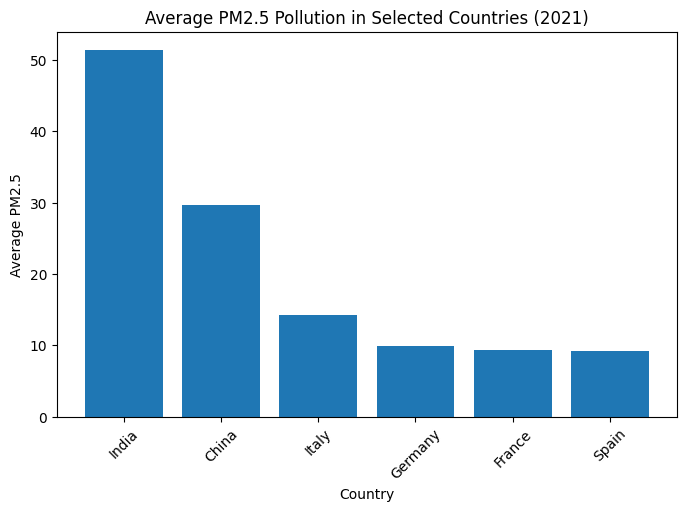

In [49]:
countries = [
    "China",
    "India",
    "Germany",
    "France",
    "Italy",
    "Spain"
]

comparison_df = df[
    df["Country"].isin(countries)
]

comparison_df = comparison_df.sort_values(
    "Avg_PM25_2021",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(
    comparison_df["Country"],
    comparison_df["Avg_PM25_2021"]
)

plt.title("Average PM2.5 Pollution in Selected Countries (2021)")
plt.xlabel("Country")
plt.ylabel("Average PM2.5")

plt.xticks(rotation=45)

plt.show()

*Answer to research question:This visualization compares average PM2.5 pollution levels across China, India, and selected European countries. The chart shows that India and China have significantly higher PM2.5 levels than Germany, France, Italy, and Spain. This suggests that air pollution is generally more severe in China and India than in the selected European countries.

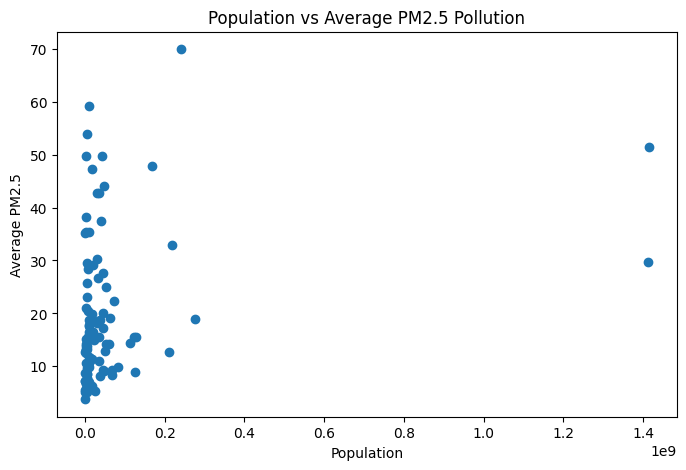

In [50]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Population"],
    df["Avg_PM25_2021"]
)

plt.title("Population vs Average PM2.5 Pollution")
plt.xlabel("Population")
plt.ylabel("Average PM2.5")

plt.show()

*Answer to research question: This scatter plot explores the relationship between population size and average PM2.5 pollution. Although some highly populated countries have high pollution levels, the points are widely dispersed and do not form a strong pattern. This indicates that population size alone does not fully explain differences in pollution levels across countries.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* If I had more time, I would investigate country name inconsistencies to improve the merge between datasets and increase the number of matched countries. I would also explore additional variables such as GDP, industrial activity, and energy consumption to better understand the factors influencing air pollution. Finally, I would perform a more detailed statistical analysis to quantify the relationship between population size and PM2.5 pollution levels.

In [1]:
import shutil

# Create a clean submission folder
shutil.rmtree("udacity_submission", ignore_errors=True)

import os
os.makedirs("udacity_submission/data/raw", exist_ok=True)
os.makedirs("udacity_submission/data/cleaned", exist_ok=True)

# Copy notebook
shutil.copy(
    "Data_Wrangling_Project_Starter.ipynb",
    "udacity_submission/Data_Wrangling_Project_2V.ipynb"
)

# Copy entire data folder
shutil.copytree(
    "data",
    "udacity_submission/data",
    dirs_exist_ok=True
)

# Create zip
shutil.make_archive(
    "udacity_submission",
    "zip",
    "udacity_submission"
)

print("Created: udacity_submission.zip")

Created: udacity_submission.zip
